In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import geopandas as gpd


In [3]:
df = pd.read_csv("L005169-082426.xlsx - Sheet1.csv")
df.head()

/var/folders/8z/9f9b14l53y99c8m3pl4l8krc0000gn/T/ipykernel_51612/912378891.py:1: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("L005169-082426.xlsx - Sheet1.csv")


,Agency,ID_Incident,StartDate,Contained,Controlled,County,FireName,Lat,Long,acres,CauseGeneral,CauseSpecific,CauseSpecificDetail,Department,BadLocation,IrwinID,Shape
0,FD,AEA0A967-E4C9-45C3-BD5F-0000D3C0A9DD,7/17/11 0:00,NaN,NaN,Wichita,Rekindle Krohn Rd,34.091480,-98.898642,0.0,Other causes,Other (remarks required),Unknown (remarks required),Electra VFD,0,NaN,0xE6100000010CF833BC5983B958C0CD1C37A1B50B4140
1,FD,5E7D8AA7-872F-4C28-849C-0001031ACCD5,4/8/20 12:59,4/8/20 13:16,4/8/20 13:52,Aransas,190,28.057600,-97.104200,0.1,Debris and open burning,Hand pile/slash,Unknown (remarks required),Rockport VFD,0,NaN,0xE6100000010C910F7A36AB4658C0E63FA4DFBE0E3C40
2,FD,A9DBA206-FB1E-4061-9500-0001FC0A547D,4/25/09 0:00,NaN,NaN,Bee,Grass Fire,28.413202,-97.723735,0.5,Smoking,Cigar/cigarette/pipe,Unknown (remarks required),Beeville Vol. Fire Dept.,0,NaN,0xE6100000010C000B70AC516E58C07CD43EA1C7693C40
3,FD,E47D6494-9964-4F0A-B4F8-0002615830C7,1/29/08 0:00,NaN,NaN,Bell,7000 Stillman Valley,30.934168,-97.716991,20.0,Debris and open burning,Hand pile/slash,Unknown (remarks required),Florence VFD,0,NaN,0xE6100000010C5002F62CE36D58C0344205A825EF3E40
4,FD,7CD8FF55-5E90-450B-8687-0002A206891B,6/17/08 0:00,NaN,NaN,Mills,Stone Creek #3,31.557167,-98.665667,1.0,Other causes,Other (remarks required),Unknown (remarks required),Mullin Volunteer Fire Department,0,NaN,0xE6100000010C874215489AAA58C01E1F6779A28E3F40


In [18]:
# How complete is each column?
quality = pd.DataFrame({
    "non_missing": df.notna().sum(),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(dropna=True)
}).sort_values("missing_pct", ascending=False)

quality

,non_missing,missing,missing_pct,unique_values
IrwinID,11056,274802,96.13,10997
Contained,97945,187913,65.74,94034
Controlled,101968,183890,64.33,95247
CauseSpecificDetail,228386,57472,20.11,54
FireName,285362,496,0.17,186733
Lat,285613,245,0.09,212636
Long,285613,245,0.09,214032
CauseSpecific,285751,107,0.04,68
CauseGeneral,285808,50,0.02,13
Agency,285858,0,0.00,2


In [19]:
checks = pd.Series({
    "Negative acres": (df["acres"] < 0).sum(),
    "Zero acres": (df["acres"] == 0).sum(),
    "Missing latitude or longitude": df[["Lat", "Long"]].isna().any(axis=1).sum(),
    "Coordinates outside rough Texas bounds": (
        ~df["Lat"].between(25, 37) | ~df["Long"].between(-107, -93)
    ).sum(),
    "Flagged BadLocation": (df["BadLocation"] == 1).sum(),
    "Missing CauseGeneral": df["CauseGeneral"].isna().sum()
})

checks

Negative acres                                1
Zero acres                                13543
Missing latitude or longitude               245
Coordinates outside rough Texas bounds      328
Flagged BadLocation                        3104
Missing CauseGeneral                         50
dtype: int64

In [29]:
print("Negative:", (df["acres"] < 0).sum())
print("Zero:", (df["acres"] == 0).sum())
print("Positive:", (df["acres"] > 0).sum())

df["acres"].describe(percentiles=[.5, .75, .90, .95, .99])

Negative: 1
Zero: 13543
Positive: 272314


count    2.858580e+05
mean     5.452653e+01
std      3.032380e+03
min     -1.000000e+00
50%      1.000000e+00
75%      5.000000e+00
90%      2.500000e+01
95%      6.700000e+01
99%      5.000000e+02
max      1.054153e+06
Name: acres, dtype: float64

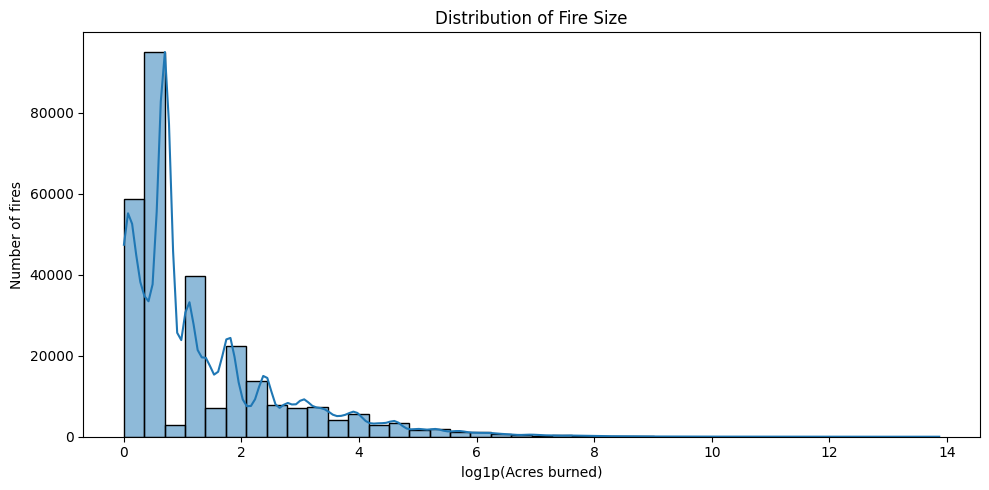

In [30]:
valid_acres = df.loc[df["acres"] >= 0, "acres"]

plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(valid_acres), bins=40, kde=True)
plt.title("Distribution of Fire Size")
plt.xlabel("log1p(Acres burned)")
plt.ylabel("Number of fires")
plt.tight_layout()
plt.show()

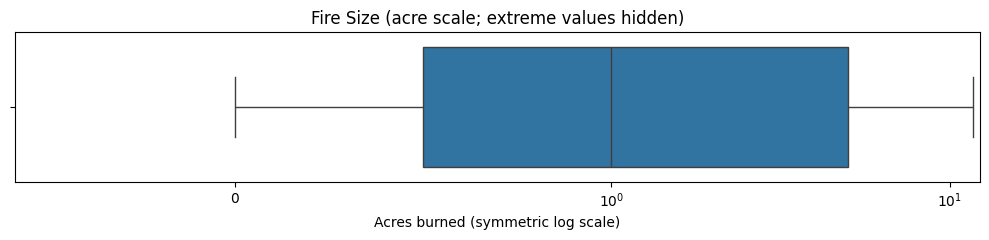

In [31]:
plt.figure(figsize=(10, 2.5))
sns.boxplot(x=valid_acres, showfliers=False)
plt.xscale("symlog", linthresh=1)
plt.title("Fire Size (acre scale; extreme values hidden)")
plt.xlabel("Acres burned (symmetric log scale)")
plt.tight_layout()
plt.show()

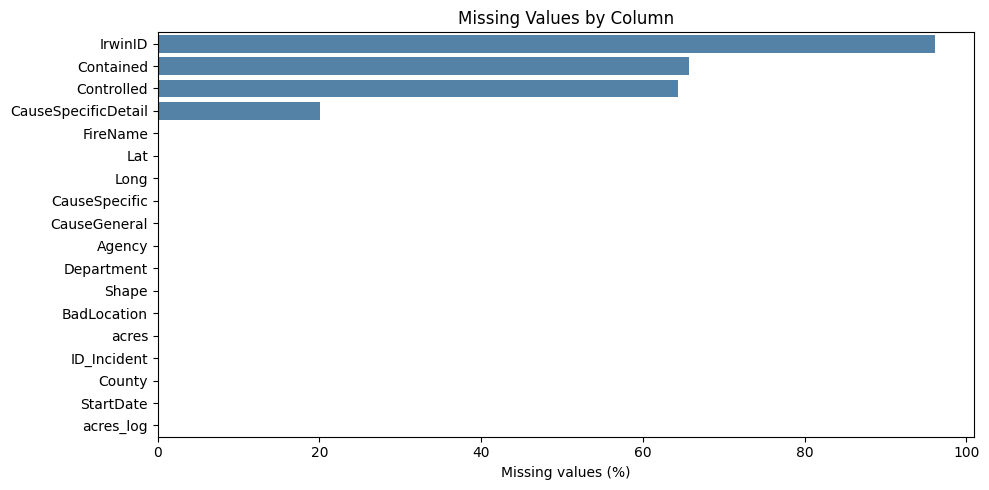

In [20]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color="steelblue")
plt.title("Missing Values by Column")
plt.xlabel("Missing values (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

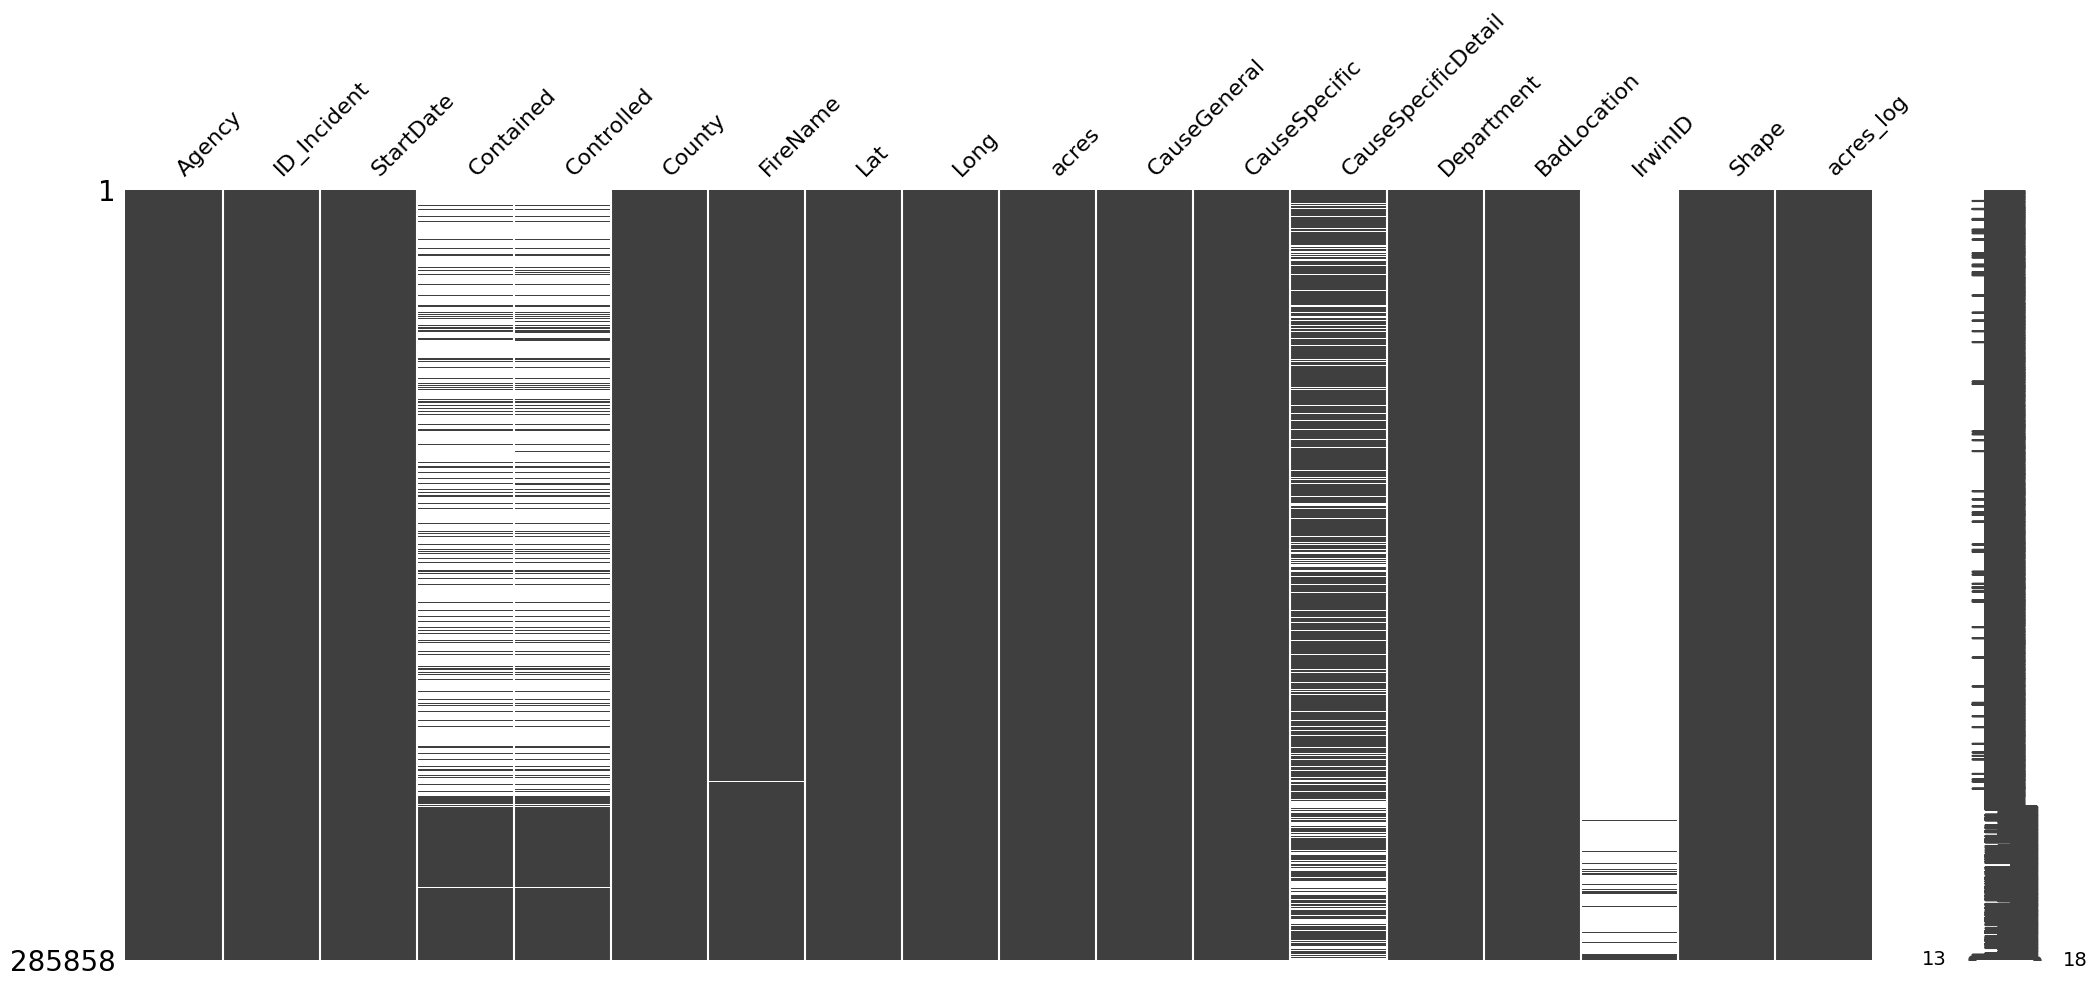

In [22]:
msno.matrix(df)
plt.show()



In [6]:
# Count of causes
cause_counts = df['CauseSpecific'].value_counts()
cause_counts

CauseSpecific
Other (remarks required)               79041
Hand pile/slash                        41297
Open trash burning                     28596
Origin and/or cause not identified     20123
Unknown (remarks required)             18375
                                       ...  
Right-of-way vegetation maintenance        1
Ceremonial fire                            1
Black powder/muzzle loading                1
Blasting                                   1
Glass refraction/magnifying glass          1
Name: count, Length: 68, dtype: int64

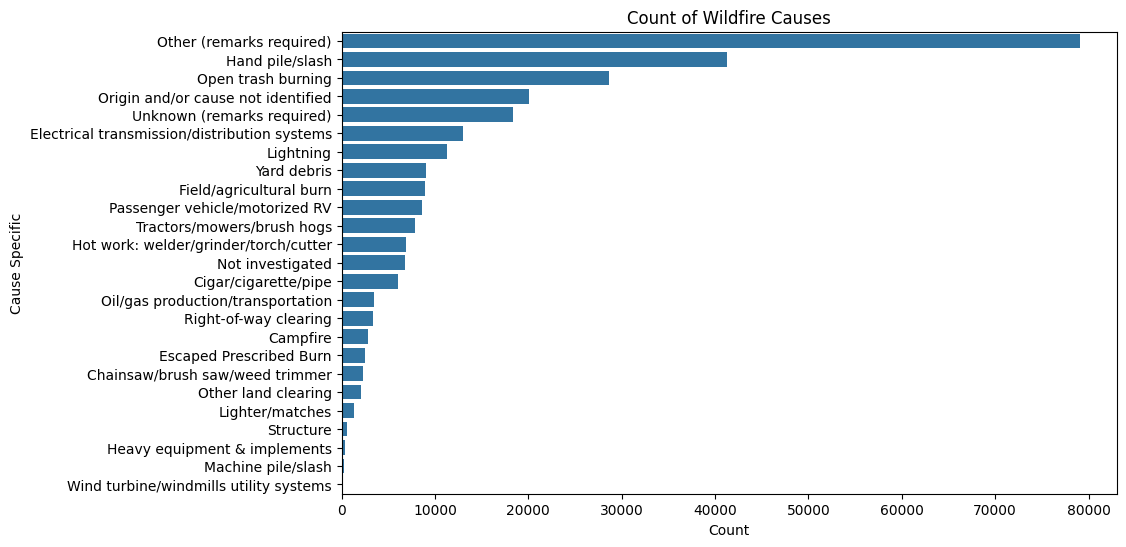

In [12]:
plt.figure(figsize=(10, 6))

sns.countplot(y='CauseSpecific', data=df, order=df['CauseSpecific'].value_counts().iloc[:25].index)
plt.title('Count of Wildfire Causes')
plt.xlabel('Count')
plt.ylabel('Cause Specific')
plt.show()

/var/folders/8z/9f9b14l53y99c8m3pl4l8krc0000gn/T/ipykernel_51612/3266914759.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["StartDate"] = pd.to_datetime(df["StartDate"], errors="coerce")


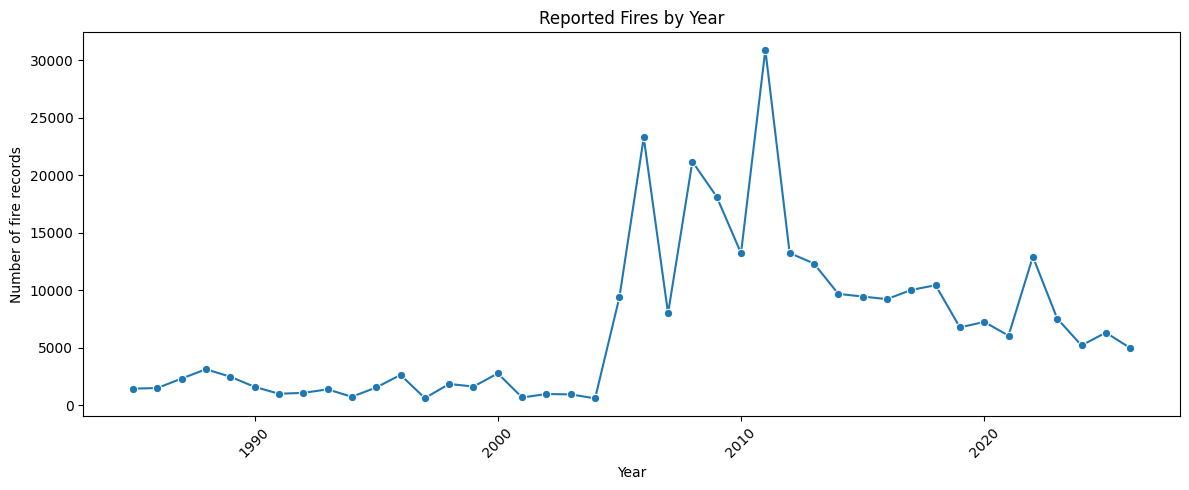

In [13]:
# Convert StartDate to datetime; invalid values become NaT
df["StartDate"] = pd.to_datetime(df["StartDate"], errors="coerce")

# Count records per year
fires_by_year = (
    df.dropna(subset=["StartDate"])
      .groupby(df["StartDate"].dt.year)
      .size()
      .rename("fire_count")
)

plt.figure(figsize=(12, 5))
sns.lineplot(x=fires_by_year.index, y=fires_by_year.values, marker="o")
plt.title("Reported Fires by Year")
plt.xlabel("Year")
plt.ylabel("Number of fire records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

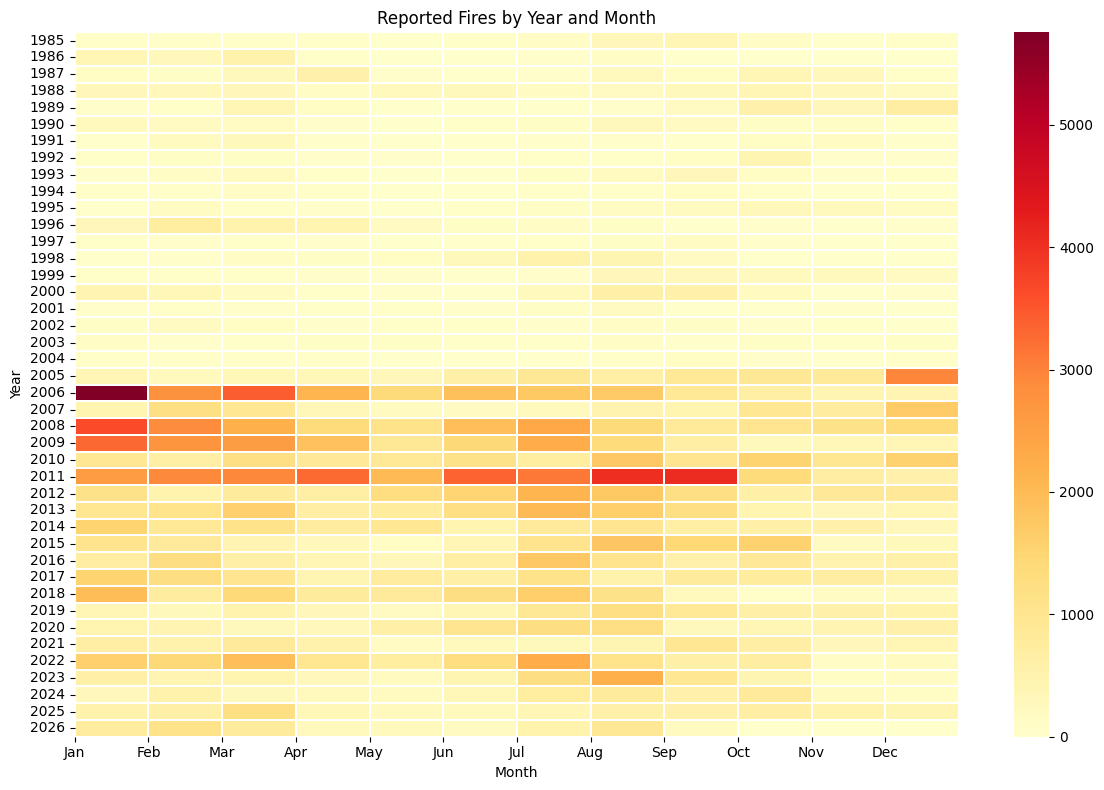

In [14]:
dated_fires = df.dropna(subset=["StartDate"]).copy()
dated_fires["year"] = dated_fires["StartDate"].dt.year
dated_fires["month"] = dated_fires["StartDate"].dt.month

fires_by_month_year = dated_fires.pivot_table(
    index="year",
    columns="month",
    values="ID_Incident",
    aggfunc="count",
    fill_value=0
)

# Ensure all months appear, even if a month has no records
fires_by_month_year = fires_by_month_year.reindex(columns=range(1, 13), fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(fires_by_month_year, cmap="YlOrRd", linewidths=0.2)
plt.title("Reported Fires by Year and Month")
plt.xlabel("Month")
plt.ylabel("Year")
plt.xticks(
    ticks=range(12),
    labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun",
            "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    rotation=0
)
plt.tight_layout()
plt.show()

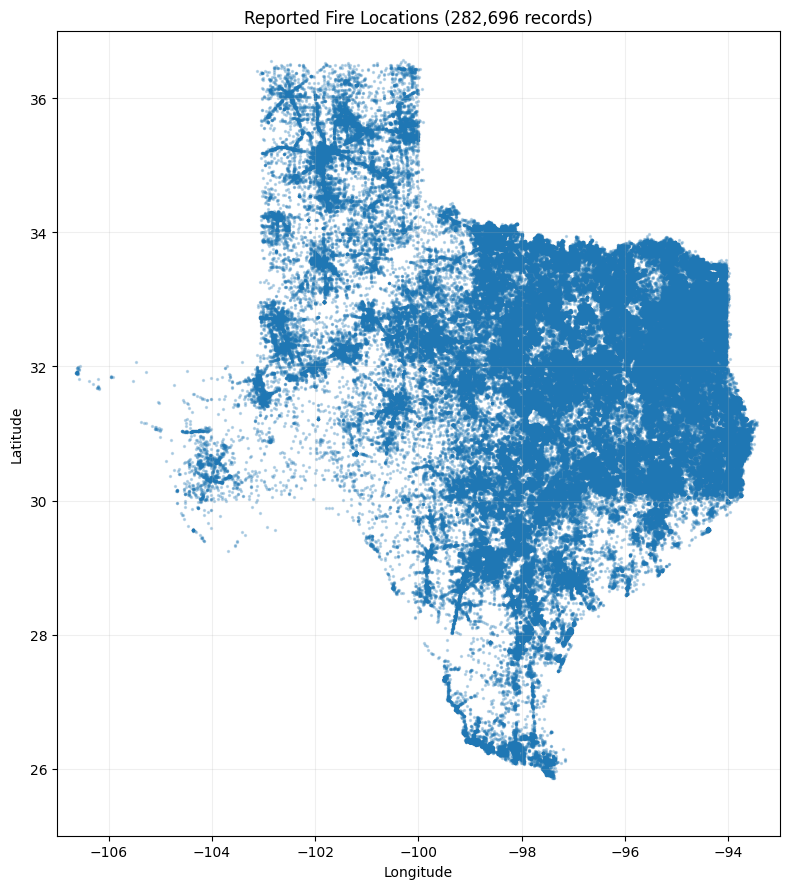

In [17]:
# Keep valid coordinates and exclude records flagged as bad
geo = df[
    df["Lat"].between(25, 37) &
    df["Long"].between(-107, -93) &
    (df["BadLocation"] == 0)
].copy()

plt.figure(figsize=(8, 9))
plt.scatter(
    geo["Long"],
    geo["Lat"],
    s=2,
    alpha=0.25
)
plt.title(f"Reported Fire Locations ({len(geo):,} records)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(-107, -93)
plt.ylim(25, 37)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

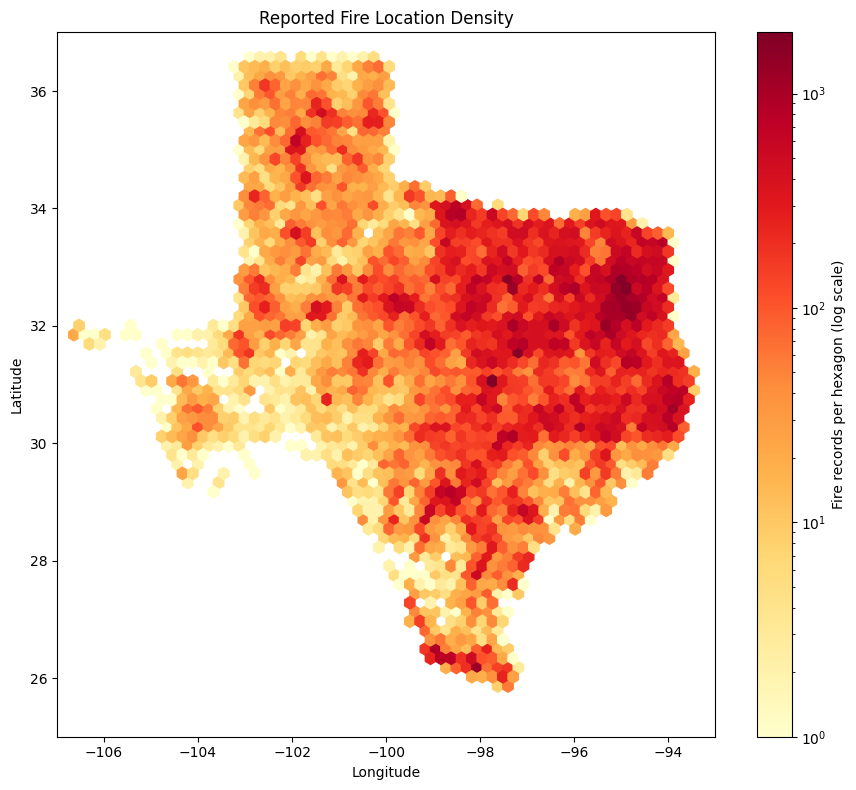

In [16]:
# Keep plausible Texas coordinates and exclude records flagged as bad
geo = df[
    df["Lat"].between(25, 37) &
    df["Long"].between(-107, -93) &
    (df["BadLocation"] == 0)
].dropna(subset=["Lat", "Long"])

plt.figure(figsize=(9, 8))

hb = plt.hexbin(
    geo["Long"],
    geo["Lat"],
    gridsize=60,       # Increase for smaller hexagons; decrease for larger ones
    mincnt=1,          # Hide empty hexagons
    bins="log",        # Makes areas with many records easier to distinguish
    cmap="YlOrRd"
)

plt.colorbar(hb, label="Fire records per hexagon (log scale)")
plt.title("Reported Fire Location Density")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(-107, -93)
plt.ylim(25, 37)
plt.tight_layout()
plt.show()

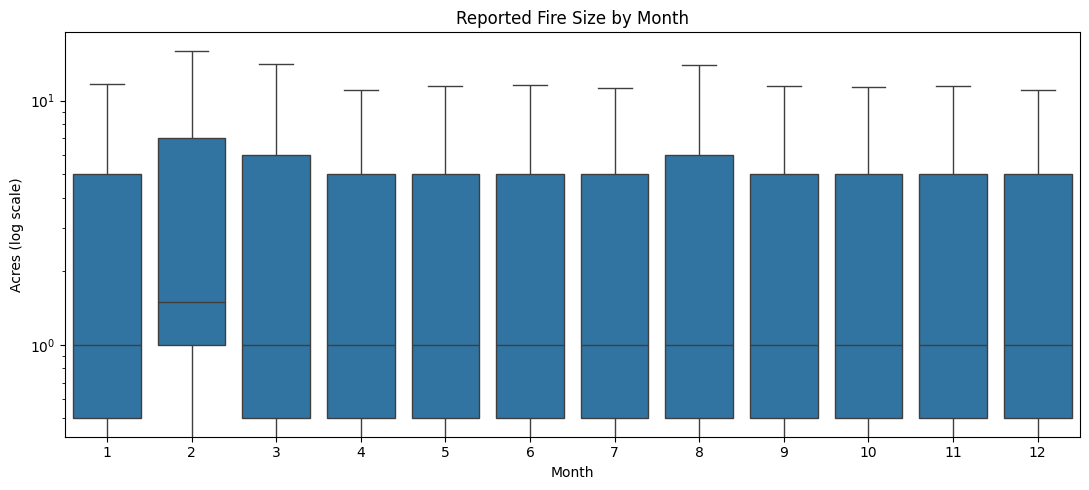

In [24]:
df["month"] = df["StartDate"].dt.month

plt.figure(figsize=(11, 5))
sns.boxplot(data=df, x="month", y="acres", showfliers=False)
plt.yscale("log")
plt.title("Reported Fire Size by Month")
plt.xlabel("Month")
plt.ylabel("Acres (log scale)")
plt.tight_layout()
plt.show()

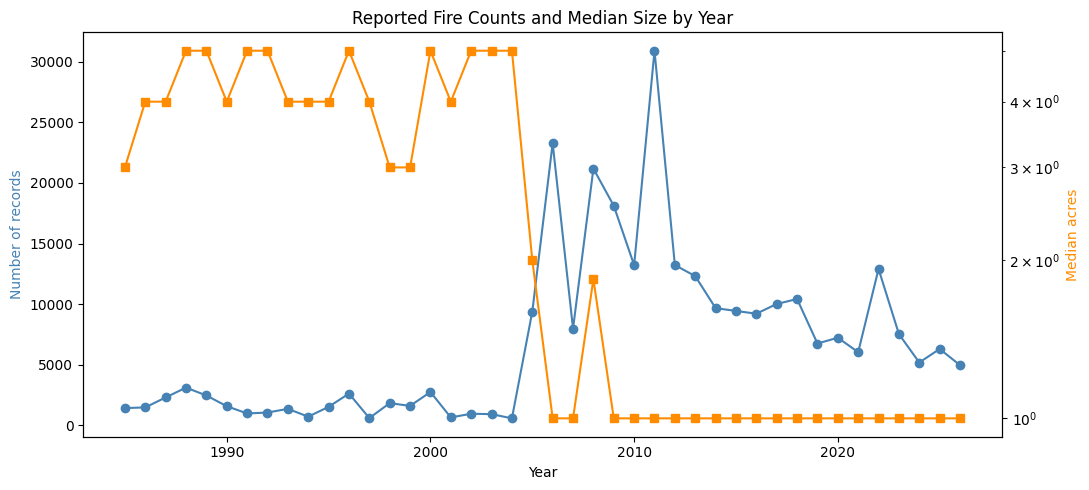

In [25]:
fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(yearly["year"], yearly["fire_count"], marker="o", color="steelblue")
ax1.set_xlabel("Year")
ax1.set_ylabel("Number of records", color="steelblue")

ax2 = ax1.twinx()
ax2.plot(yearly["year"], yearly["median_acres"], marker="s", color="darkorange")
ax2.set_ylabel("Median acres", color="darkorange")
ax2.set_yscale("log")

plt.title("Reported Fire Counts and Median Size by Year")
fig.tight_layout()
plt.show()

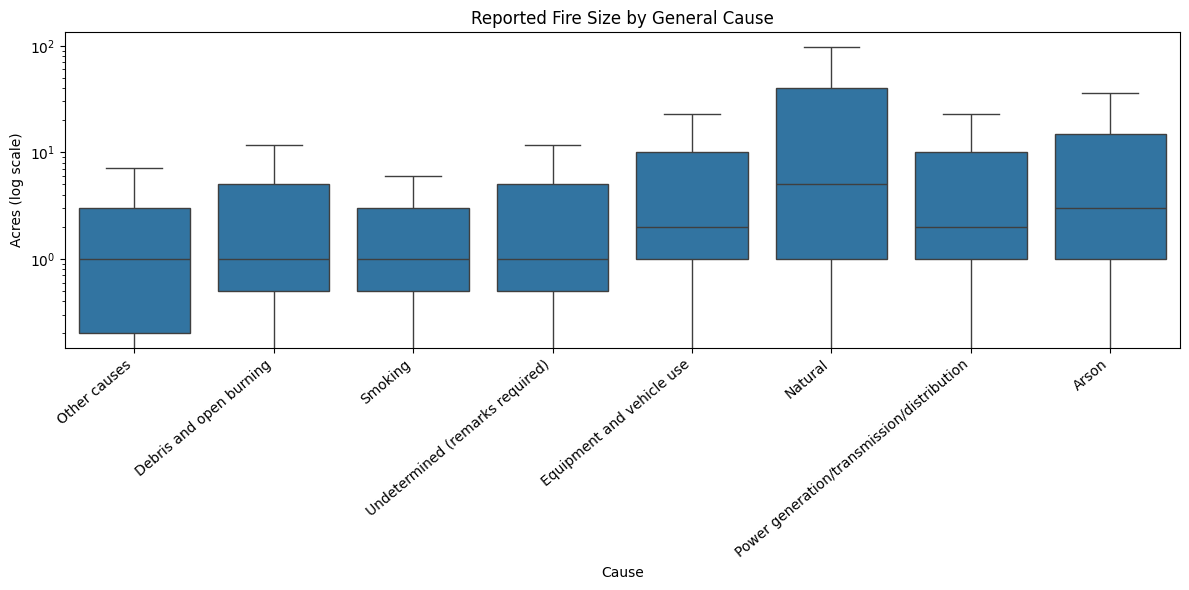

In [26]:
top_causes = df["CauseGeneral"].value_counts().head(8).index
cause_data = df[df["CauseGeneral"].isin(top_causes)].copy()

plt.figure(figsize=(12, 6))
sns.boxplot(data=cause_data, x="CauseGeneral", y="acres", showfliers=False)
plt.yscale("log")
plt.xticks(rotation=40, ha="right")
plt.title("Reported Fire Size by General Cause")
plt.xlabel("Cause")
plt.ylabel("Acres (log scale)")
plt.tight_layout()
plt.show()

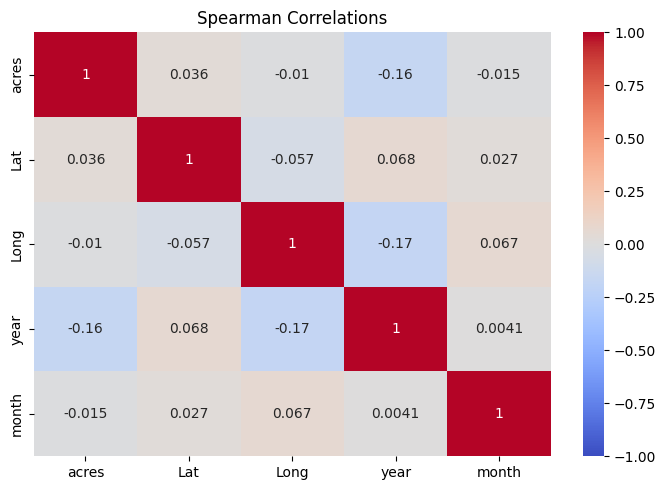

In [28]:
corr_data = dated.assign(
    year=dated["StartDate"].dt.year,
    month=dated["StartDate"].dt.month
)[["acres", "Lat", "Long", "year", "month"]]

corr = corr_data.corr(method="spearman")

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Spearman Correlations")
plt.tight_layout()
plt.show()

In [34]:
import geopandas as gpd

# Keep valid coordinates and exclude records flagged as bad
geo_df = df[
    df["Lat"].between(25, 37) &
    df["Long"].between(-107, -93) &
    (df["BadLocation"] == 0)
].dropna(subset=["Lat", "Long"]).copy()

fires_gdf = gpd.GeoDataFrame(
    geo_df,
    geometry=gpd.points_from_xy(geo_df["Long"], geo_df["Lat"]),
    crs="EPSG:4326"  # Longitude/latitude coordinates
)

fires_gdf.head()

,Agency,ID_Incident,StartDate,Contained,Controlled,County,FireName,Lat,Long,acres,...,CauseSpecific,CauseSpecificDetail,Department,BadLocation,IrwinID,Shape,acres_log,year,month,geometry
0,FD,AEA0A967-E4C9-45C3-BD5F-0000D3C0A9DD,2011-07-17 00:00:00,NaN,NaN,Wichita,Rekindle Krohn Rd,34.091480,-98.898642,0.0,...,Other (remarks required),Unknown (remarks required),Electra VFD,0,NaN,0xE6100000010CF833BC5983B958C0CD1C37A1B50B4140,0.000000,2011,7,POINT (-98.89864 34.09148)
1,FD,5E7D8AA7-872F-4C28-849C-0001031ACCD5,2020-04-08 12:59:00,4/8/20 13:16,4/8/20 13:52,Aransas,190,28.057600,-97.104200,0.1,...,Hand pile/slash,Unknown (remarks required),Rockport VFD,0,NaN,0xE6100000010C910F7A36AB4658C0E63FA4DFBE0E3C40,0.095310,2020,4,POINT (-97.1042 28.0576)
2,FD,A9DBA206-FB1E-4061-9500-0001FC0A547D,2009-04-25 00:00:00,NaN,NaN,Bee,Grass Fire,28.413202,-97.723735,0.5,...,Cigar/cigarette/pipe,Unknown (remarks required),Beeville Vol. Fire Dept.,0,NaN,0xE6100000010C000B70AC516E58C07CD43EA1C7693C40,0.405465,2009,4,POINT (-97.72373 28.4132)
3,FD,E47D6494-9964-4F0A-B4F8-0002615830C7,2008-01-29 00:00:00,NaN,NaN,Bell,7000 Stillman Valley,30.934168,-97.716991,20.0,...,Hand pile/slash,Unknown (remarks required),Florence VFD,0,NaN,0xE6100000010C5002F62CE36D58C0344205A825EF3E40,3.044522,2008,1,POINT (-97.71699 30.93417)
4,FD,7CD8FF55-5E90-450B-8687-0002A206891B,2008-06-17 00:00:00,NaN,NaN,Mills,Stone Creek #3,31.557167,-98.665667,1.0,...,Other (remarks required),Unknown (remarks required),Mullin Volunteer Fire Department,0,NaN,0xE6100000010C874215489AAA58C01E1F6779A28E3F40,0.693147,2008,6,POINT (-98.66567 31.55717)


In [35]:
county_summary = (
    fires_gdf.groupby("County")
    .agg(
        fire_count=("ID_Incident", "count"),
        total_acres=("acres", "sum"),
        median_acres=("acres", "median")
    )
    .reset_index()
)

county_summary.sort_values("total_acres", ascending=False).head(10)

,County,fire_count,total_acres,median_acres
116,Hutchinson,1068,2108385.82,2.00
121,Jeff Davis,435,528764.09,10.00
147,Lipscomb,266,446673.40,22.50
29,Callahan,1766,408001.00,1.00
21,Brewster,156,325513.51,10.25
181,Palo Pinto,2776,317229.49,1.00
170,Moore,286,277469.25,1.00
1,Andrews,1014,277106.45,2.00
185,Pecos,163,267847.02,5.00
89,Gray,368,262121.20,5.00
